## MATTEO MARCO COSTA - PROGETTO 7 
### Corso di  DEEP LEARNING by Profession AI

### Il Problema da Risolvere
L'azienda TechTalk, un forum per appassionati di tecnologia, ha riscontrato che un numero significativo di commenti pubblicati nei thread della community contiene espressioni di odio e insulti che compromettono la qualità delle discussioni. Gli utenti hanno segnalato che la piattaforma, a causa della sua popolarità crescente, fatica a gestire il flusso di commenti dannosi con strumenti di moderazione tradizionali. TechTalk si è rivolta a DeepCortex AI Solutions per implementare una soluzione di moderazione automatica basata su Deep Learning, che sia in grado di filtrare in tempo reale i commenti tossici.

<br>

### Caso d'Uso
Scenario reale: Mario Rossi, community manager di TechTalk, si occupa quotidianamente della moderazione manuale dei contenuti generati dagli utenti. Con l’aumento del traffico sulla piattaforma, Mario non riesce più a gestire manualmente la quantità di commenti dannosi, e deve trovare un modo per filtrare automaticamente i commenti offensivi, minacciosi o osceni senza rallentare l'esperienza utente.

<br>

### Requisiti Tecnici del Modello
1) Task: Classificazione multi-label dei commenti in 6 categorie:

* Toxic (Tossico)
* Severely Toxic (Super Tossico)
* Obscene (Osceno)
* Threat (Minaccia)
* Insult (Insulto)
* Identity Hate (Odio basato sull’identità)

<br>

2) Dataset: Un dataset di 160.000 commenti sarà fornito, con ogni commento etichettato in una o più delle categorie sopra indicate. I commenti possono avere zero o più label attive.

3) Architettura: Il modello deve includere layer ricorrenti (ad esempio, LSTM o GRU) per gestire la natura sequenziale dei commenti testuali.

4) Output: A livello di inferenza, per ogni commento, il modello dovrà produrre un vettore di 6 elementi (uno per ogni label), con valori binari (0 o 1), dove 1 indica la presenza della label corrispondente e 0 la sua assenza.

<br>

### Fasi del Progetto
* Preprocessing dei Dati: i commenti testuali devono essere convertiti in sequenze numeriche (tokenizzazione). I dati devono essere normalizzati e bilanciati per garantire che tutte le categorie di tossicità siano rappresentate equamente.

* Sviluppo del Modello: il modello di deep learning sarà basato su un'architettura ricorrente, in grado di catturare le dipendenze a lungo termine tra le parole nei commenti.
Verranno implementati strati ricorrenti (LSTM o GRU) per il task di classificazione multi-label.

* Training del Modello: il dataset sarà suddiviso in training, validation e test set.
Utilizzo di tecniche di ottimizzazione avanzata per migliorare la convergenza del modello.

* Inferenza e Predizione: durante il tempo di inferenza, per ogni commento, il modello restituirà un vettore di 6 elementi con 0 o 1, a seconda della presenza di tossicità in una o più delle categorie previste.

* Validazione: il modello sarà valutato utilizzando metriche come accuracy, F1-score per ciascuna categoria, e precisione globale nella previsione delle label multiple.

### Fasi implementative
Per la costruzione del filtro adotteremo le Reti Neurali Ricorrenti (RNN), in particolare una loro variante avanzata: le Long Short-Term Memory (LSTM). Le LSTM sono progettate per superare alcune limitazioni delle RNN tradizionali, come il problema del vanishing gradient, risultando quindi più efficaci in compiti che richiedono la modellazione di dipendenze a lungo termine.
L’architettura delle RNN — e delle LSTM — è di tipo feedforward, ma con la caratteristica distintiva di includere una “memoria” interna, che consente alla rete di conservare informazioni rilevanti nel tempo. Questa proprietà le rende particolarmente adatte per applicazioni come il language modeling e l’elaborazione di sequenze temporali.

#### Import delle librerie
Di seguito iniziamo a importare tutte le librerie necessarie alla costruzione del filtro.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re, random
from collections import Counter
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GRU
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.utils import resample
from keras.layers import BatchNormalization

#### 1) Data Exploration
In questa fase iniziale, analizziamo il file CSV di input contenente la lista dei commenti associati alle rispettive classificazioni. L’obiettivo è comprendere la struttura dei dati al fine di applicare le opportune tecniche di data cleaning e data preparation, propedeutiche all’addestramento della rete LSTM finale.

In [2]:
#Import csv
file_path = 'Filter_Toxic_Comments_dataset.csv'
df = pd.read_csv(file_path)

#Print di alcune righe
df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,sum_injurious
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,0


Usando la info() function, proviamo a vedere se esistono valori a missing:

In [3]:
print(f"{df.info()}")
print(f"Struttura del dataset: righe {df.shape[0]}, colonne {df.shape[1]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   comment_text   159571 non-null  object
 1   toxic          159571 non-null  int64 
 2   severe_toxic   159571 non-null  int64 
 3   obscene        159571 non-null  int64 
 4   threat         159571 non-null  int64 
 5   insult         159571 non-null  int64 
 6   identity_hate  159571 non-null  int64 
 7   sum_injurious  159571 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 9.7+ MB
None
Struttura del dataset: righe 159571, colonne 8


Non sembrano esserci valori mancanti dato che il numero di valori non-null coincide con le righe
totali per ogni variabile. Di seguito, proseguiamo ad analizzare le tipologie di commenti all'interno del dataset basandoci sulle varie label.

Conteggio per la variabile 'toxic': {0: 144277, 1: 15294}


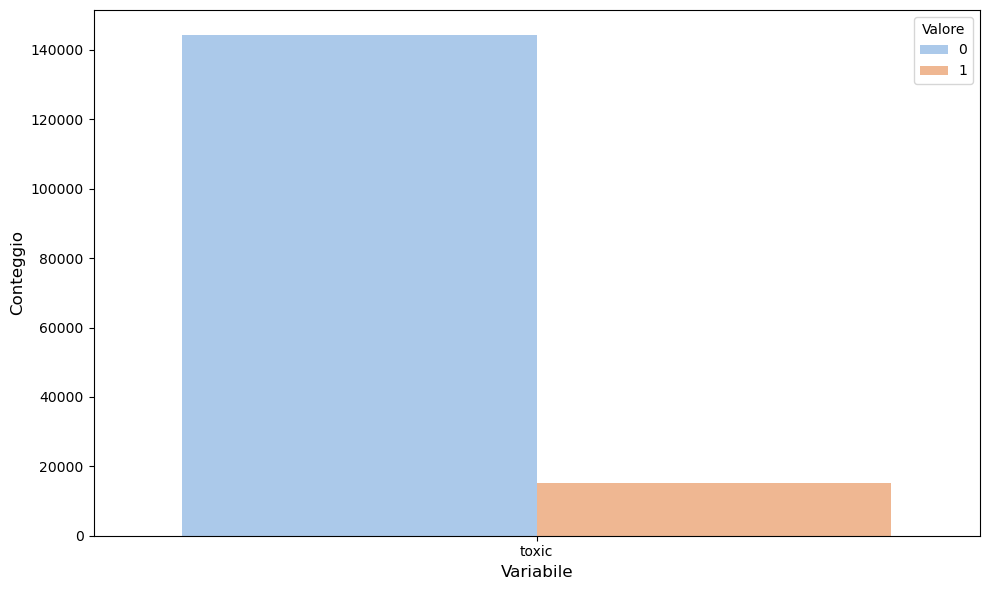

Conteggio per la variabile 'severe_toxic': {0: 157976, 1: 1595}


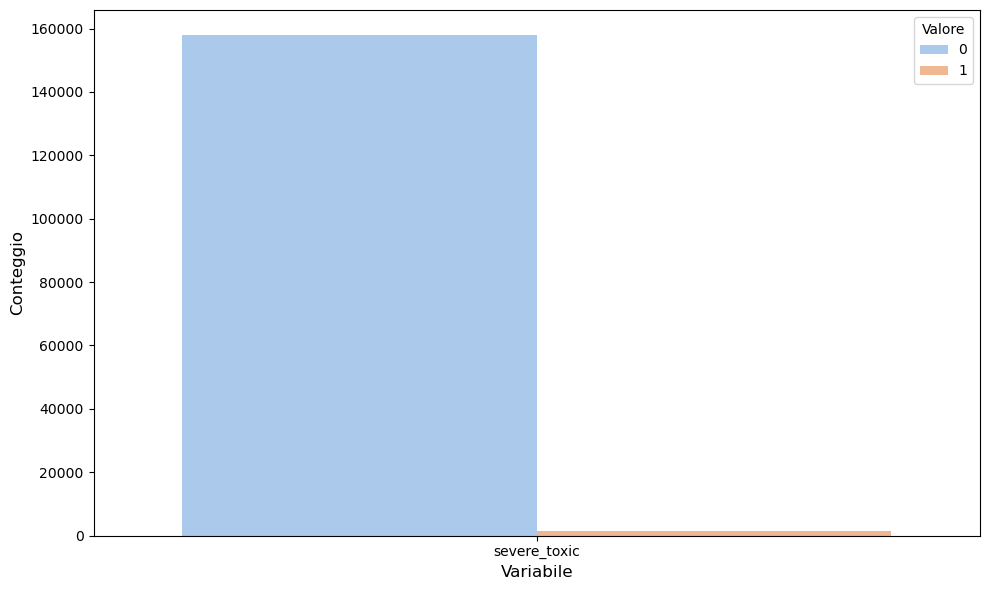

Conteggio per la variabile 'obscene': {0: 151122, 1: 8449}


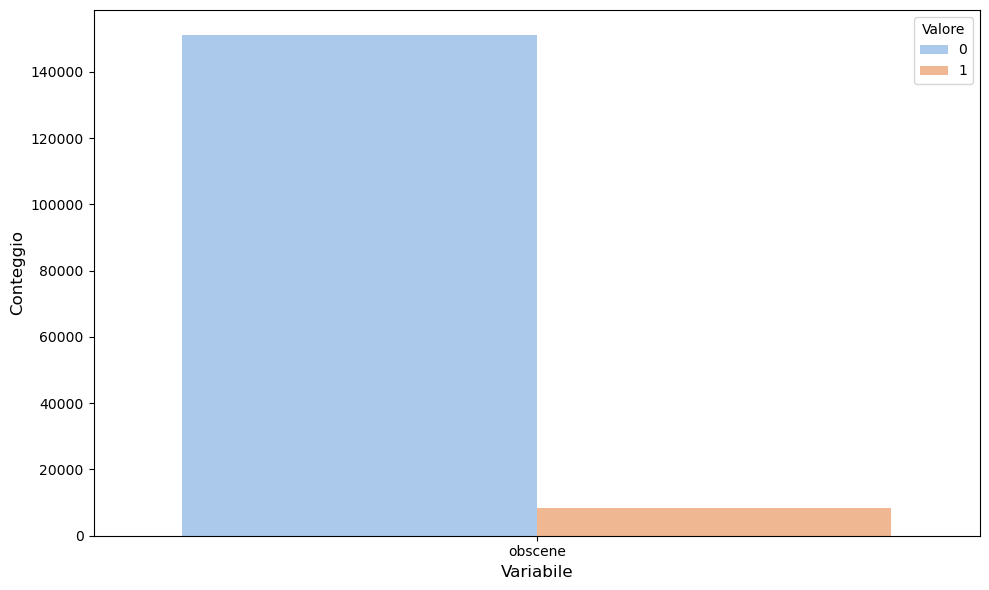

Conteggio per la variabile 'threat': {0: 159093, 1: 478}


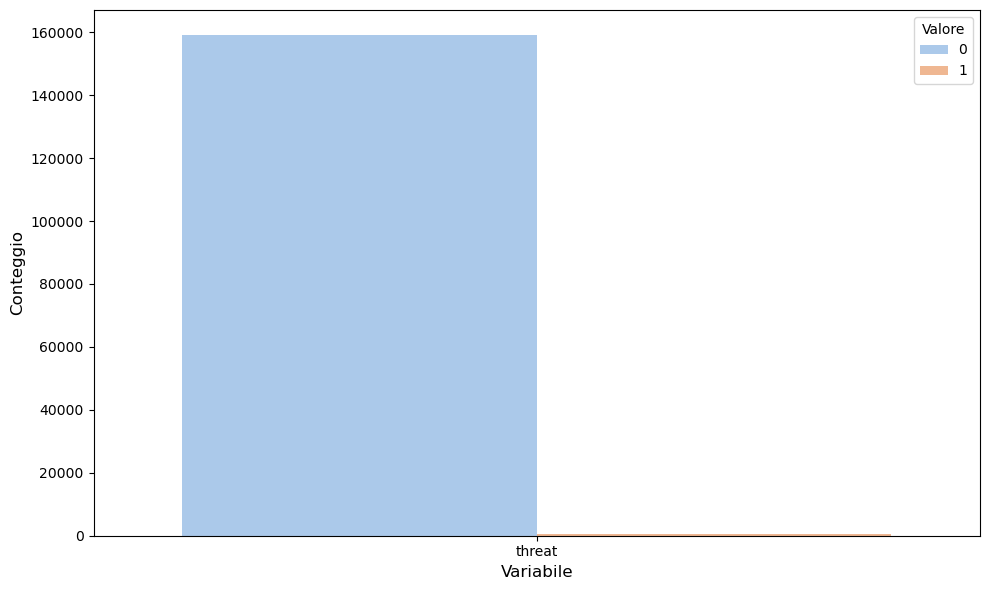

Conteggio per la variabile 'insult': {0: 151694, 1: 7877}


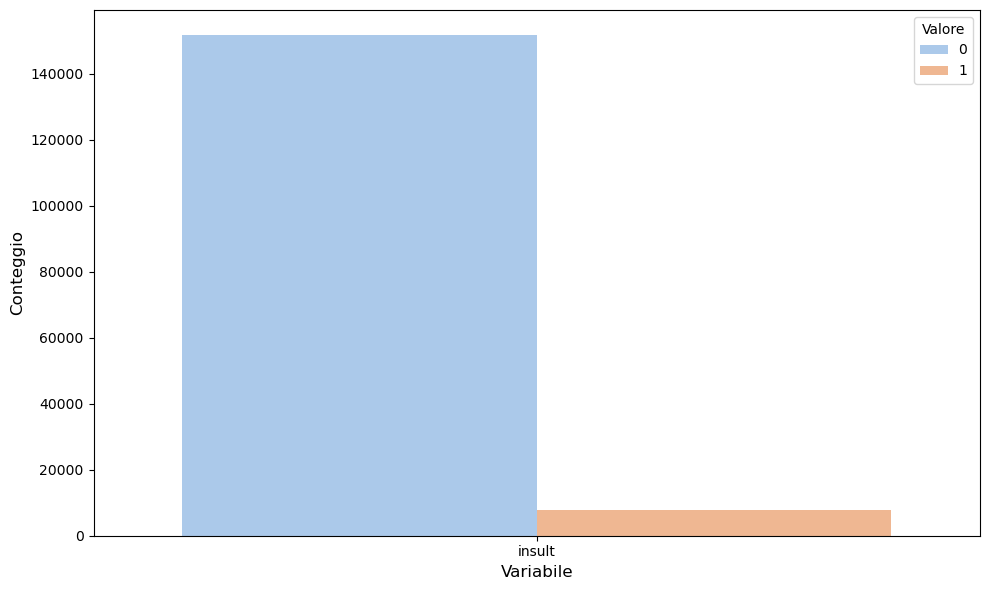

Conteggio per la variabile 'identity_hate': {0: 158166, 1: 1405}


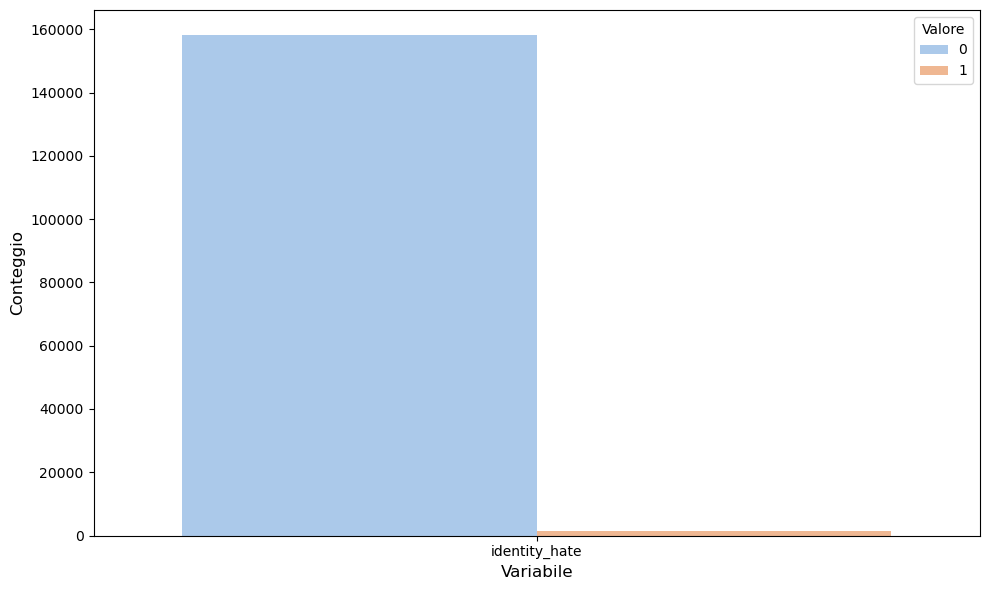

In [4]:
#Analisi delle 6 label singolarmente: istogramma delle frequenze assolute, uso della melt function

#Lista delle possibili classificazioni
categories = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
    
for x in categories:   
    df_melted = pd.melt(df[[x]], var_name='Variabile', value_name='Valore')
    
    #Report di conteggio
    conteggio = Counter(df[x])
    print(f"Conteggio per la variabile '{x}': {dict(conteggio)}")

    #Grafico finale
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_melted, x='Variabile', hue='Valore', palette='pastel')
    plt.xlabel("Variabile", fontsize=12)
    plt.ylabel("Conteggio", fontsize=12)
    plt.legend(title="Valore", labels=["0", "1"])
    plt.tight_layout()
    plt.show()

Possiamo notare che per ogni tipologia di classificazione, c'è una forte disparità tra 0 e 1. Questo evidente sbilanciamento potrebbe sicuramente causare problemi in fase di training. Inoltre questa disparità sussiste anche nel caso multilabel, come possiamo osservare qui di seguito:

In [5]:
#Analisi multilabel: uso della colonna sum_injurious
injurious = df[df['sum_injurious']>=1].shape[0]
not_injurious = df[df['sum_injurious']==0].shape[0]

perc_injurious = injurious/(injurious + not_injurious)
perc_not_injurious = 1 - perc_injurious

print(f"injurious: {perc_injurious} --- not injurious: {perc_not_injurious}")

injurious: 0.10167887648758234 --- not injurious: 0.8983211235124177


Come già anticipato, osservando le singole colonne, la classificazione multilabel ha una forte disparità. Nella sezione dedicata al data modeling, introdurremo una tecnica di oversampling in versione multilabel per gestire questo problema.

#### 2) Data Preparation
Nella metodologia delle LSTM, la fase di data preparation può essere riassunta nei seguenti step principali. Partendo dal dataset contenente le varie recensioni, procederemo seguendo questa metodologia:

<br>

* Undersampling: leggera diminuzione delle recensioni non tossiche;
* Data Cleaning: rimozione di eventuali caratteri speciali, riduzione a stessa formatazzione;
* Tokenizzazione: trasformare il testo in sequenze di numeri interi;
* Padding: padding delle sequenze per ottenere una lunghezza uniforme.

#### 2.1) Undersampling

In [6]:
X = df.drop(columns=['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'])
y = df[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']]

#Identifica le righe in base alla colonna "sum_injuries"
non_tossici = X[X['sum_injurious'] == 0].index#Istanza non tossica (sum_injuries = 0)
tossici = X[X['sum_injurious'] > 0].index#Istanza tossica (sum_injuries > 0)

#Riduzione del numero di istanze non tossiche (undersampling)
undersampled_non_tossici = resample(non_tossici, 
                                    replace = False,#Senza sostituzione
                                    n_samples = int((80/20)*len(tossici)),#Proporzione
                                    random_state = 42)

#Combina tossici e non tossici sottocampionati
balanced_indices = list(undersampled_non_tossici)+list(tossici)

#Seleziona le righe corrispondenti agli indici bilanciati
X_balanced = X.loc[balanced_indices].reset_index(drop=True)
y_balanced = y.loc[balanced_indices].reset_index(drop=True)

In [7]:
# Riassembla X_balanced e y_balanced in un unico DataFrame
df_balanced = pd.concat([X_balanced, y_balanced], axis=1)

#Check sul nuovo DataFrame
df_balanced.head()

,comment_text,sum_injurious,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,"""\n\nOh, don't worry about me, Sandstein. I'm ...",0,0,0,0,0,0,0
1,Are you trying to dispute that fact?,0,0,0,0,0,0,0
2,SWOT analysis \n\nThis source – Align Technolo...,0,0,0,0,0,0,0
3,"cover \n\nso, do we want a current or older co...",0,0,0,0,0,0,0
4,P.S. It's probably worth setting up a template...,0,0,0,0,0,0,0


In [8]:
#Check finale
injurious = df_balanced[df_balanced['sum_injurious']>=1].shape[0]
not_injurious = df_balanced[df_balanced['sum_injurious']==0].shape[0]

perc_injurious = injurious/(injurious + not_injurious)
perc_not_injurious = 1 - perc_injurious

print(f"injurious: {perc_injurious} --- not injurious: {perc_not_injurious}")
print(f"{df_balanced.shape}")

injurious: 0.2 --- not injurious: 0.8
(81125, 8)


#### 2.2) Gestione dei caratteri speciali

In [9]:
#Formattazione dei commenti: cerchiamo di eliminare eventuali caratteri speciali. Possiamo usare
#le regex function.

def clean_text(text):
    text = text.lower()#Conversione di ogni commento in minuscolo
    text = re.sub(r"(?<!\w)'(?!\w)", "", text)#Rimozione di apostrofi non significativi
    text = re.sub(r'\s+', ' ', text).strip()#Rimozione di evenutali spazi multipli
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)#Rimozione caratteri non latini
    
    #Seleziona solo frasi con più di un carattere (filtra frasi troppo brevi)
    sentences = re.findall(r'[^.?!\n]+', text)#Trova le frasi
    
    #Filtra le frasi troppo corte
    sentences = [sentence.strip() for sentence in sentences if len(sentence.strip()) > 1]
    
    #Uniamo le frasi filtrate in un unico testo
    text = ' '.join(sentences)
    return text

#Applichiamo la function ai commenti
df_balanced['comment_text'] = df_balanced['comment_text'].apply(clean_text)

In [10]:
#Check post cleaning
print(df_balanced['comment_text'].iloc[1050:1060])

1050    drprinceton github is the top place where new ...
1051    searching such nonconvex hull over a finite se...
1052    wpchicago leadership this month you have indic...
1053                          able to do better than that
1054    i await my lashingslol maybe they will see on ...
1055    lock this page up been too much vandalism on i...
1056    rebuild i enjoyed this page when i first saw i...
1057    i did use that hint during a game of taboo tho...
1058    template2012olympicathleticsschedule hi the da...
1059    colt cabana lol youre joking he actually has a...
Name: comment_text, dtype: object


#### 2.3) Tokenizzazione
Nei modelli di elaborazione del linguaggio naturale, questa fase consiste nel trasformare il testo grezzo in unità comprensibili per il modello. Si inizia a dividere ogni testo (nel nostro caso ogni commento) in parole (unità) a cui si associa un numero univoco che andrà a popolare un rispettivo dizionario. Il processo terminerà con una fase, detta di padding, dove le varie sequenze vengono uniformate a una lunghezza prefissata per essere compatibili con il modello. Per effettuare queste fasi utilizzeremo tool appositi presi dalla libreria tensorflow.

In [11]:
#1)Selezione del testo (ovvero dei commenti del csv) e delle rispettive labels. La variabile categories
#contiene l'elenco delle colonne che descrivono la tipologia di commento
texts = df_balanced['comment_text'].values
labels = df_balanced[categories].values

Per la fase di tokenizzazione che segue, impostiamo il parametro OOV. In questo modo, ogni parola che non rientra tra le prime max_words più comuni (o che non è presente nel vocabolario) verrà automaticamente sostituita con il token oov.
Quando si adotta il metodo texts_to_sequences, tutte le parole non presenti nel dizionario verranno mappate all'indice del token oov.
Il token oov verrà assegnato a un indice durante il processo di fit_on_texts, tipicamente il primo indice (ad esempio 1), a meno che non siano presenti altre configurazioni.
E' preferibile impostare questo parametro poichè altrimenti le parole sconosciute non verranno rappresentate in alcun modo, risultando in una sequenza più corta e potenzialmente distorta rispetto al testo originale. Senza tale parametro si potrebbe intercorrere in problemi di generalizzazione e perdita di informazione in fase modellistica.

In [12]:
#2)Tokenizer: creazione dell'oggetto token
max_words = 5000
tokenizer = Tokenizer(num_words = max_words, oov_token="<oov>")

#---> #Prime 5000 più comuni per la creazione del dizionario

#Uso della fit_on_texts: analisi di tutti i commenti per creare il dizionario (word_index) che 
#associerà in modo univoco ogni parola a un numero intero.
tokenizer.fit_on_texts(texts)

In [13]:
#Check delle parole complessive nel dizionario
num_words_in_dict = len(tokenizer.word_index)
print(f"Numero totale di parole nel dizionario: {num_words_in_dict}")

Numero totale di parole nel dizionario: 154882


In [14]:
#Visualizza le prime 10 parole più frequenti nel dizionario
for word, index in list(tokenizer.word_index.items())[:10]:
    print(f"Parola: {word}, Indice: {index}")

Parola: <oov>, Indice: 1
Parola: the, Indice: 2
Parola: to, Indice: 3
Parola: you, Indice: 4
Parola: and, Indice: 5
Parola: a, Indice: 6
Parola: of, Indice: 7
Parola: i, Indice: 8
Parola: is, Indice: 9
Parola: that, Indice: 10


In [15]:
#Check sulla percentuale di copertura: le 5000 parole scelte sono sufficienti?

#1)Frequenze delle parole nel dizionario
word_counts = tokenizer.word_counts  # Dizionario: parola -> frequenza

#2)Somma delle frequenze delle parole considerate e totale
top_words_freq = sum(freq for word, freq in word_counts.items() if tokenizer.word_index[word] <= 5000)
total_freq = sum(word_counts.values())

#3)Percentuale di copertura
coverage = (top_words_freq / total_freq) * 100
print(f"Le prime 5.000 parole coprono il {coverage:.2f}% del corpus totale.")

Le prime 5.000 parole coprono il 89.49% del corpus totale.


Dato che le prime 5000 parole comprono all'incirca il 90% del corpo totale dei testi, optiamo per il valore 5000.

In [16]:
#texts_to_sequences: conversione di ogni commento in una sequenza di numeri tramite il dizionario per
#la successiva fase di padding
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index

In [18]:
#Check sul primo commento
print(f"Frase 1: {texts[1]}")
print(f"Tokenizer vector per frase 1: {sequences[1]}")

Frase 1: are you trying to dispute that fact
Tokenizer vector per frase 1: [18, 4, 247, 3, 612, 10, 164]


#### 2.4) Padding
La funzione pad_sequences è utilizzata per garantire che tutte le sequenze di parole (dopo la tokenizzazione) abbiano la stessa lunghezza dato che le LSTM o GRU richiedono input di dimensioni costanti. In presenza di sequenze con lunghezza diversa, la pad_sequences le riempie con 0 (di default) per renderle tutte della stessa lunghezza, che si può definire tramite il parametro maxlen. Per la determinazione del parametro ottimale, optiamo per la seguente strategia: proviamo a studiare la distribuzione delle frequenze assolute delle lunghezze dei singoli commenti.

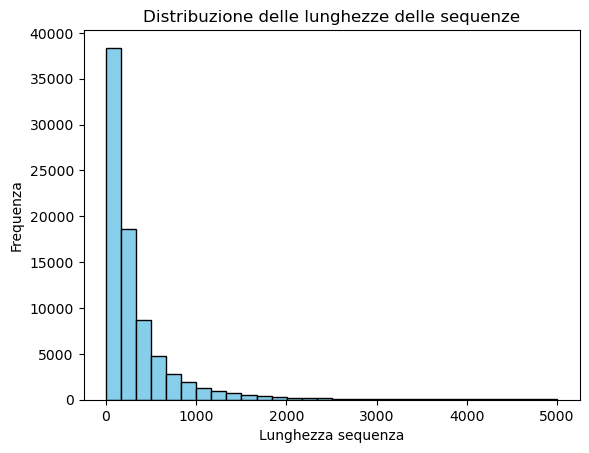

In [19]:
#Determinazione max_sequence_length e successiva applicazione

#Calcolo delle lunghezze
sequence_lengths = [len(seq) for seq in texts]

#Creazione di un istogramma di frequenze assolute
plt.hist(sequence_lengths, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribuzione delle lunghezze delle sequenze')
plt.xlabel('Lunghezza sequenza')
plt.ylabel('Frequenza')
plt.show()

La distribuzione sembra quella di una legge esponenziale. Per la determinazione del parametro ottimale di lunghezza (max_sequence_length) optiamo per il'80-esimo percentile della distribuzione.

In [20]:
#max_sequence_length (80-esimo percentilie)
max_sequence_length = np.percentile(sequence_lengths, 80)
print(f"max_sequence_length: {int(max_sequence_length)}")

max_sequence_length: 482


In [21]:
#Padding: applicazione del padding col valore ottimale: in base all'osservazione precedente optiamo
#per una valore pari a 480
max_sequence_length = 480
data_padded = pad_sequences(sequences, maxlen = max_sequence_length)

#### 3) Modellizzazione della rete neurale
Terminata la fase di data preparation, possiamo passare alla costruzione della LSTM. A tal proposito, adotteremo le funzionalità delle librerie tensorflow e keras. 

#### 3.1) Architettura della LSTM
L'architettura della LSTM che andremo a costruire prevederà la presenza di 6 layers:

<br>

* Layer 1 (Embedding): questo primo layer trasforma gli indici interi delle parole (ottenuti nella fase di tokenizzazione) in vettori densi di dimensione fissa;
* Layer 2 (LSTM): elaborazione delle sequenze mantenendo informazioni di lungo termine grazie alla sua struttura ricorrente, uso di 64 neuroni nel layer, valorizzazione a True per connettersi al LSTM layer successivo;
* Layer 3 (BatchNormalization): può essere utile tra i layer LSTM e dopo il layer Dense per stabilizzare il training;
* Layer 4 (Dropout): livello intermedio per riduzione di eventuali overfitting;
* Layer 5 (LSTM): secondo LSTM layer;
* Layer 6 (BatchNormalization)
* Layer 7 (Dropout): un secondo livello intermedio per riduzione di eventuali overfitting;
* Layer 8 (Dense): essendo un problema di classificazione multilabel, per il layer finale optiamo a un layer che preveda come funzione di attivazione una sigmoide a 6 stati.

<br>

Per ora ci baseremo su questa struttura; chiaramente, può sempre essere ottimizzata aggiungendo più layers nello strato nascosto. 

<br>

NB: è buona prassi applicare una clear_session() prima del lancio di una nuova rete in fase di testing.

In [22]:
#LSTM: architettura neurale: il parametro max_words corrisponde al numero massimo di parole del vocabolario
K.clear_session()

model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_sequence_length),
    LSTM(64, return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),
    LSTM(64),
    BatchNormalization(),
    Dropout(0.2),
    Dense(6, activation='sigmoid')#Uso della sigmoide: si tratta di un task multilabel
])

#output_dim=128 ---> Ogni parola viene trasformata in un vettore di dimensione 128. 

In [23]:
#Check sull'architettura neurale
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 480, 128)          640000    
                                                                 
 lstm (LSTM)                 (None, 480, 64)           49408     
                                                                 
 batch_normalization (BatchN  (None, 480, 64)          256       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 480, 64)           0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                33024     
                                                                 
 batch_normalization_1 (Batc  (None, 64)               256       
 hNormalization)                                        

#### 3.2) Training,Test & Validation set
Di seguito costruiamo i vari sottoinsiemi del dataset necessari al training e alla validazione del modello. Da richieste progettuali, si richiede anche la costruzione di un test set finale su cui verificare ulteriormente la bontà del modello costruito. Nello specifico, possiamo riassumere il tutto nei seguenti step:

<br>

* 1) costruzione del training set per addestrare il modello;
* 2) costruzione del validation set: utilizzato per ottimizzare i parametri del modello e monitorare l'overfitting durante l'addestramento;
* 3) costruzione del test set: usato per valutare le performance finali del modello su dati mai visti.

In [24]:
#Training e test set: 30% dei dati assegnato al test set. Inoltre, per le label, bisogna creare 
#una vettorizzazione essendo un problema di classificazione multilabel
X = data_padded
y = df_balanced[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']].values

X.shape

(81125, 480)

In [25]:
#Step 1: divisione iniziale in due set: il primo servirà per venire poi risuddiviso in training e
#e validation set (X_temp e y_temp) mentre la seconda parte servirà come test set (X_test, y_test). 
#Il test set corrisponderà al 20% del dataset complessivo. 
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Step 2: divisione in training e validation per il training del modello (divideremo dal X_temp e y_temp).
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.30, random_state=42)

#Check dimensioni
print(f"Dimensione Training Set: {len(X_train)}")
print(f"Dimensione Validation Set: {len(X_val)}")
print(f"Dimensione Test Set: {len(X_test)}")

Dimensione Training Set: 45430
Dimensione Validation Set: 19470
Dimensione Test Set: 16225


#### 3.3) Oversampling multilabel
Come anticipato nelle sezioni iniziali, la distribuzione di 0 e 1 per ogni tipologia di commento non è
ben distribuita. Ora che abbiamo a disposizione il set di training, applicheremo una tecnica di 
oversampling in modo da ribilanciare le classi di 0 e 1. Esitono pacchetti come MSMOTE; nel nostro caso
optiamo a una costruzione manuale.

In [26]:
#Funzione per trovare le etichette rare (tail labels)
def get_tail_label(df):
    columns = df.columns
    n = len(columns)
    irpl = np.zeros(n)
    for column in range(n):
        irpl[column] = df[columns[column]].value_counts()[1]
    irpl = max(irpl)/irpl
    mir = np.average(irpl)
    tail_label = []
    for i in range(n):
        if irpl[i] > mir:
            tail_label.append(columns[i])
    return tail_label

#Funzione per ottenere gli indici delle righe con etichette rare
def get_index(df):
    tail_labels = get_tail_label(df)
    index = set()
    for tail_label in tail_labels:
        sub_index = set(df[df[tail_label] == 1].index)
        index = index.union(sub_index)
    return list(index)

#Funzione per ottenere le istanze minoritarie (con etichette rare)
def get_minority_instance(X, y):
    index = get_index(y)
    X_sub = X[X.index.isin(index)].reset_index(drop=True)
    y_sub = y[y.index.isin(index)].reset_index(drop=True)
    return X_sub, y_sub

#Funzione per trovare i vicini più prossimi
def nearest_neighbour(X):
    nbs = NearestNeighbors(n_neighbors=5, metric='euclidean', algorithm='kd_tree').fit(X)
    _, indices = nbs.kneighbors(X)
    return indices

#Funzione MLSMOTE per generare nuovi campioni sintetici
def MLSMOTE(X, y, n_sample):
    indices2 = nearest_neighbour(X)
    n = len(indices2)
    new_X = np.zeros((n_sample, X.shape[1]))
    target = np.zeros((n_sample, y.shape[1]))
    
    for i in range(n_sample):
        reference = random.randint(0, n-1)
        neighbour = random.choice(indices2[reference, 1:])
        all_point = indices2[reference]
        
        #Calcola la somma delle etichette dei vicini e crea una nuova etichetta
        nn_df = y[y.index.isin(all_point)]
        ser = nn_df.sum(axis=0, skipna=True)
        target[i] = np.array([1 if val > 2 else 0 for val in ser])
        
        #Interpola tra il campione di riferimento e il vicino
        ratio = random.random()
        gap = X.loc[reference, :] - X.loc[neighbour, :]
        new_X[i] = np.array(X.loc[reference, :] + ratio * gap)
    
    new_X = pd.DataFrame(new_X, columns=X.columns)#Creare un DataFrame per new_X
    target = pd.DataFrame(target, columns=y.columns)#Creare un DataFrame per y_res
    
    #Concatenare i dati originali con i nuovi campioni sintetici
    new_X = pd.concat([X, new_X], axis=0)
    target = pd.concat([y, target], axis=0)
    return new_X, target

In [27]:
#Conversione X_train e y_train in DataFrame se sono numpy.ndarray
X_train = pd.DataFrame(X_train)
y_train = pd.DataFrame(y_train)

#Passaggio 1: identificazione delle etichette rare
X_sub, y_sub = get_minority_instance(X_train, y_train)#Estrai le istanze minoritarie

#Passaggio 2: applicazione del MLSMOTE per generare nuovi campioni sintetici
X_res, y_res = MLSMOTE(X_sub, y_sub, n_sample=100)#Genera 100 nuovi campioni sintetici

#---> Assicurarsi che i valori siano nel range [0, max_words-1]
X_res = X_res.clip(lower=0, upper=max_words-1)

#Passaggio 3: uniamo i dati originali con i nuovi campioni sintetici
X_train_resampled = pd.concat([X_train, X_res], axis=0)#Concatenare X_train con X_res
y_train_resampled = pd.concat([y_train, y_res], axis=0)#Concatenare y_train con y_res

#Ora possiamo usare X_train_resampled e y_train_resampled per il training del modello
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')

print(f'Nuovo X_train shape: {X_train_resampled.shape}')
print(f'Nuovo y_train shape: {y_train_resampled.shape}')

X_train shape: (45430, 480)
y_train shape: (45430, 6)
Nuovo X_train shape: (47239, 480)
Nuovo y_train shape: (47239, 6)


#### Model compile
Di seguito compiliamo il modello tramite il comando compile. Nello specifico, adotteremo la tecnica
di ottimizzazione ADAM (Adaptive Moment Estimation). Ricordiamo alcuni vantaggi di questa tecnica:

* Momentum: riduce le oscillazioni nei minimi locali grazie al mantenimento di una media ponderata dei gradienti passati;
* RMSprop: adatta il tasso di apprendimento per ciascun parametro in base alla media quadratica dei gradienti recenti, rendendo l'aggiornamento robusto e adattivo.

#### Scelta della funzione di loss
Come funzione di loss optiamo per la binary crossentropy; essendo di fronte a un problema multilabel,
tale funzione risulta ottimale allo scopo, in particolare:

<br>

* adatta per problemi multilabel: nel nostro caso abbiamo 6 classificazioni, ciascuna indipendente. La BCE funziona bene per problemi multilabel poiché valuta separatamente la previsione di ciascuna etichetta;
* compatibilità con la sigmoide nello strato finale: l'output della funzione sigmoide produce valori tra 0 e 1, perfetti per BCE;
* la BCE è una funzione differenziabile, pertanto è ben supportata dall'ottimizzazione Adam.

In [28]:
#Compilazione della LSTM: uso della binary_crossentropy, più adatta per un problema multilabel
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.002),
              loss='binary_crossentropy',
              metrics=['accuracy', 'Precision', 'Recall', 'AUC'])#Monitoraggio delle metriche

In [29]:
#Costruzione di una tecnica di early stopping
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(monitor='val_loss',#Quale metrica monitorare per l'overfitting
                               patience=3,#Permette al modello di continuare per 3 epoche senza migliorare prima di fermarsi
                               restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.5, 
                              patience=2, 
                              min_lr=1e-6)#Impedisce che il learning rate diventi troppo piccolo

In [30]:
#Training del modello
history = model.fit(X_train, y_train, batch_size=64,
                    epochs=5, 
                    validation_data=(X_val, y_val), 
                    callbacks=[early_stopping, reduce_lr])

Epoch 1/5
305/710 [===========>..................] - ETA: 10:55 - loss: 0.2690 - accuracy: 0.4914 - precision: 0.3887 - recall: 0.5792 - auc: 0.8554

KeyboardInterrupt: 

In [29]:
#Costruzione della curve di learning: costruzione delle liste necessarie
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
train_precision = history.history['precision']
val_precision = history.history['val_precision']

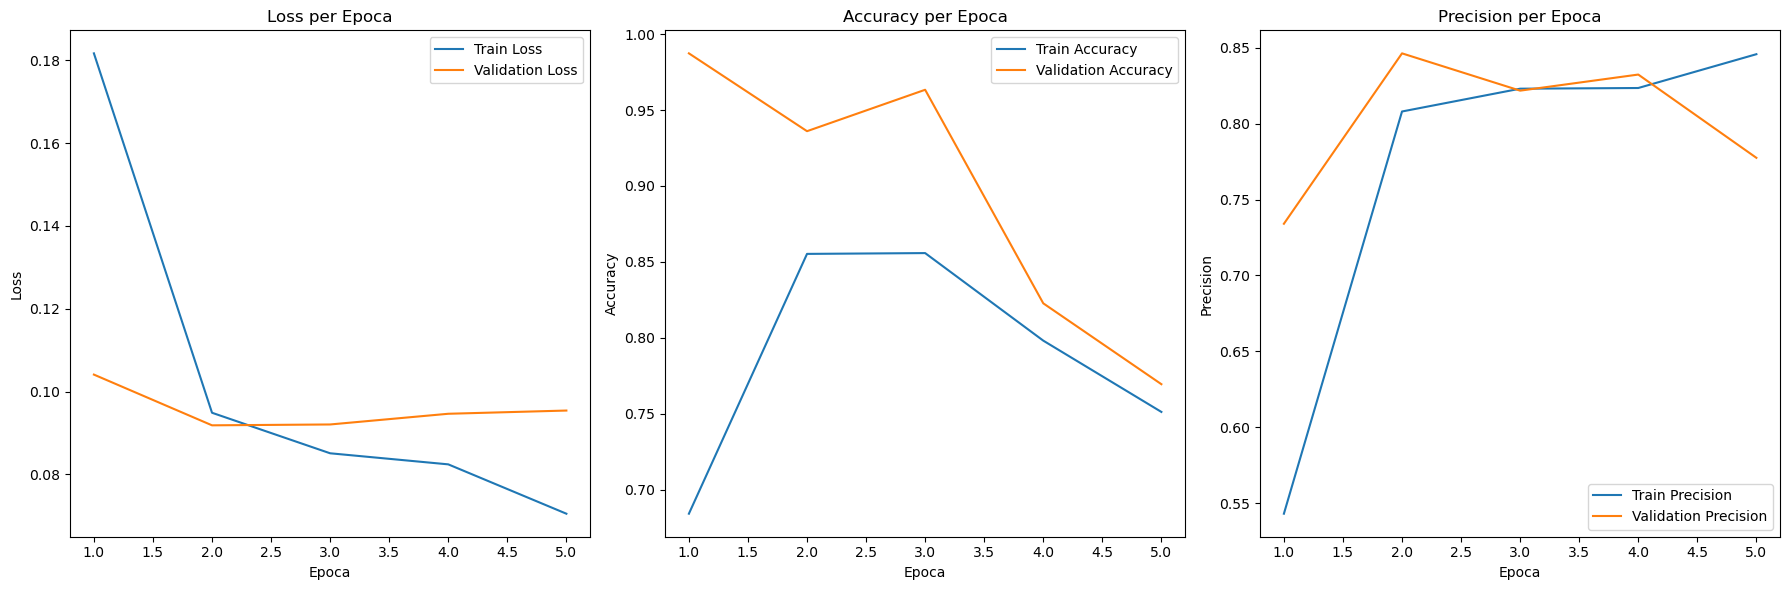

In [31]:
#Plot delle learning curves
plt.figure(figsize=(18, 6))

#A) Curva della Loss
plt.subplot(1, 3, 1)  # Cambiato a 1x3 per fare spazio alla Precisione
plt.plot(range(1, 6), train_loss, label='Train Loss')
plt.plot(range(1, 6), val_loss, label='Validation Loss')
plt.title('Loss per Epoca')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()

#B) Curva dell'Accuracy
plt.subplot(1, 3, 2)
plt.plot(range(1, 6), train_accuracy, label='Train Accuracy')
plt.plot(range(1, 6), val_accuracy, label='Validation Accuracy')
plt.title('Accuracy per Epoca')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.legend()

#C) Curva della Precision
plt.subplot(1, 3, 3)
plt.plot(range(1, 6), train_precision, label='Train Precision')
plt.plot(range(1, 6), val_precision, label='Validation Precision')
plt.title('Precision per Epoca')
plt.xlabel('Epoca')
plt.ylabel('Precision')
plt.legend()

#Grafico finale
plt.tight_layout()
plt.show()

In [34]:
#Test del modello sui dati di validazione (che corrispondeva al 30% del dataset)
results = model.evaluate(X_test, y_test)
print("Test Loss:", results[0])  # Il primo valore è la loss
print("Test Accuracy:", results[1])  # Il secondo valore è l'accuracy
print("Test Precision:", results[2])  # Se precision è la terza metrica
print("Test Recall:", results[3])  # Se recall è la quarta metrica
print("Test AUC:", results[4])  # Se auc è la quinta metrica

508/508 [==============================] - 124s 242ms/step - loss: 0.0875 - accuracy: 0.9357 - precision: 0.8516 - recall: 0.6400 - auc: 0.9752
Test Loss: 0.08753061294555664
Test Accuracy: 0.9357165098190308
Test Precision: 0.8516141772270203
Test Recall: 0.6400175094604492
Test AUC: 0.9752036333084106


#### 4) Testing del modello
Proviamo a effettuare qualche test del modello creato su una lista di commenti mai vista prima.

In [37]:
#Creiamo una lista di commenti
new_comments = ["You are horrible!", 
                "What a wonderful day!", 
                "Fuck you!",
                "beautiful!",
                "I hate you and your family! Stupid man!",
                "You are my little pretty sunshine"]
new_sequences = tokenizer.texts_to_sequences(new_comments)
new_data_padded = pad_sequences(new_sequences, maxlen=max_sequence_length)
predictions = (model.predict(new_data_padded) > 0.5).astype(int)

#Risultati
for comment, pred in zip(new_comments, predictions):
    print(f"Commento: {comment}")
    print(f"Predizione: {dict(zip(categories, pred))}")

1/1 [==============================] - 0s 256ms/step
Commento: You are horrible!
Predizione: {'toxic': 1, 'severe_toxic': 0, 'obscene': 0, 'threat': 0, 'insult': 0, 'identity_hate': 0}
Commento: What a wonderful day!
Predizione: {'toxic': 0, 'severe_toxic': 0, 'obscene': 0, 'threat': 0, 'insult': 0, 'identity_hate': 0}
Commento: Fuck you!
Predizione: {'toxic': 1, 'severe_toxic': 0, 'obscene': 1, 'threat': 0, 'insult': 1, 'identity_hate': 0}
Commento: beautiful!
Predizione: {'toxic': 0, 'severe_toxic': 0, 'obscene': 0, 'threat': 0, 'insult': 0, 'identity_hate': 0}
Commento: you are an horrible fucking asshole nigga!
Predizione: {'toxic': 1, 'severe_toxic': 0, 'obscene': 1, 'threat': 0, 'insult': 1, 'identity_hate': 0}
Commento: You are my little pretty sunshine
Predizione: {'toxic': 0, 'severe_toxic': 0, 'obscene': 0, 'threat': 0, 'insult': 0, 'identity_hate': 0}


In [39]:
#Salvataggio del modello (NB. h5 è un formato di salvataggio tipico per salvare modelli di deep learning)
model.save("lstm_model_1")

#Riutilizzo del modello: in caso di riutilizzo, si può richiamare il modello salvato senza dovero
#riaddestrare tutto da capo. Il formato h5 tiene conto dell'architettura della rete e di tutti i
#dettagli intrischi dall'applicazione della compile function.
from tensorflow.keras.models import load_model
model_loaded = load_model("lstm_model_1")

INFO:tensorflow:Assets written to: lstm_model_1\assets


INFO:tensorflow:Assets written to: lstm_model_1\assets
